# Homework 3
### ASTR 324, Spring 2026, Ivezic, University of Washington

https://github.com/uw-astr-324/astr-324-s26


## Homework submission procedure: 

* You will be sending me your executed (with all the plots etc) *.ipynb files via email

* the Subject: line **must be** "astr-324-s26-FirstLast-HW?, where FirstLast is your first
and last name, and ? will be 1, 2, 3 or 4. 

* For example: astr-324-s26-ZeljkoIvezic-HW1

* I will be recognizing and downloading your submissions using a script. If you don't 
follow the above, your HW will not be recognized.

* Your homework email **must be sent** before Thursday class (that is, before 10am)
two weeks after that homework was assigned (e.g. HW1 will be available by the start of Thursday 
class on April 9, and will be due by 10am on April 23).

 

## Problem 1

Use **PyMC** to fit this function to the provided dataset (see below): 
$y(x) = A * x * np.cos(B*x) + C$. Show plots with
the progress of chains, the corner plot, and a plot that shows data (with uncertainties for both x and y axis)
and the best-fit model. What are the values of the best-fit model parameters (give 95% credible intervals)? 


## Problem 2

Use **emcee** to fit two functions to the provided dataset (see below).

**Function 1:** 5-th order polynomial, $y(x) = \sum_{j=0}^5 c_j \, x^j$.

**Function 2:** $y(x) = A * x * np.cos(B*x) + C$. 

Show plots with
the progress of chains and the corner plots for both models, and a plot that shows data (with uncertainties for y axis) and both best fit models. Which model is a better description of provided data? How strong is the evidence? 


## Problem 3

Apply Bayesian Blocks Algorithm to period distribution of LINEAR variable stars (see below) and
compare the result to classical (Knuth's) uniform bin width histogram.
Plot histograms on both linear and log scale. 

## Problem 4

These questions are similar to those that you will be asked on the final exam. Please answer each one with 1-3 sentences. 

* What does Markov Chain Monte Carlo method do?  

* What can Metropolis-Hastings algorithm do? 

* What is Bayesian Blocks algorithm useful for? How is it different from Knuth's histogram? 

# Homework 3: Solutions

### Some useful definitions and functions

In [1]:
import numpy as np 
from matplotlib import pyplot as plt
from scipy.stats import norm

# MCMC library
import pymc as pm
# analysis and visualization helper for pymc
import arviz as az

# here we are using emcee
import emcee 
import corner 

%matplotlib inline

Write your solutions below...

## Problem 1

### dataset to fit:

In [2]:
xObs = np.array([0.0, 0.26315789, 0.52631579, 0.78947368, 1.05263158, 1.31578947, 1.57894737, 1.84210526, 2.10526316, 2.36842105, 2.63157895, 2.89473684, 3.15789474, 3.42105263, 3.68421053, 3.94736842, 4.21052632, 4.47368421, 4.73684211, 5.0])
yObs = np.array([-0.01519999,  0.32530142,  0.62251935,  0.53022095,  0.49561467, 0.50552021,  0.07149746, -0.54528213, -1.01273784, -1.74602254, -2.34787813, -2.78038444, -3.36781022, -3.47795891, -3.21682447, -2.84510209, -1.99096649, -1.1576002 , -0.03944155,  1.57943597])
xErr = np.array([0.10993428, 0.09723471, 0.11295377, 0.1304606 , 0.09531693, 0.09531726, 0.13158426, 0.11534869, 0.09061051, 0.1108512, 0.09073165, 0.0906854 , 0.10483925, 0.0617344 , 0.06550164, 0.08875425, 0.07974338, 0.10628495, 0.08183952, 0.07175393])
yErr = np.array([0.10993428, 0.09723471, 0.11295377, 0.1304606 , 0.09531693, 0.09531726, 0.13158426, 0.11534869, 0.09061051, 0.1108512, 0.09073165, 0.0906854 , 0.10483925, 0.0617344 , 0.06550164, 0.08875425, 0.07974338, 0.10628495, 0.08183952, 0.07175393])

In [3]:
# hint: use these prior ranges for model parameters 
thetaMin = (-1.0, -2.0, -2.0, -2.0, -2.0, -2.0)
thetaMax = ( 1.0,  2.0,  2.0,  2.0,  2.0,  2.0)

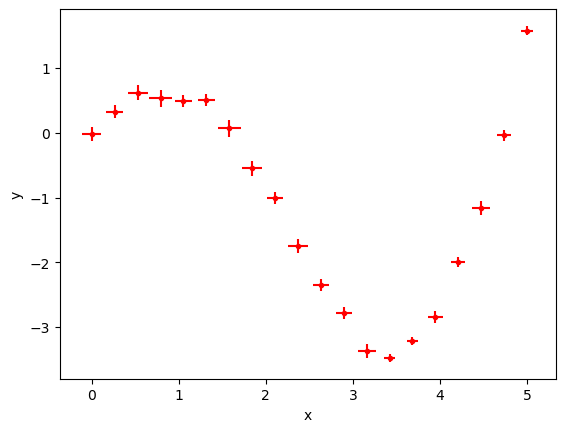

In [4]:
# let's take a look at the data  
ax = plt.figure().add_subplot(111)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.errorbar(xObs, yObs, xerr=xErr, yerr=yErr, color='r', marker='.', ls='None', label='data')
plt.show() 

In [5]:
# here comes your work

## Problem 2

### here we will use emcee, not pymc

In [6]:
### this is the provided dataset to fit (note that x errors are assumed negligible): 
xObs = np.array([0.0, 0.26315789, 0.52631579, 0.78947368, 1.05263158, 1.31578947, 1.57894737, 1.84210526, 2.10526316, 2.36842105, 2.63157895, 2.89473684, 3.15789474, 3.42105263, 3.68421053, 3.94736842, 4.21052632, 4.47368421, 4.73684211, 5.0])
yObs = np.array([-0.01519999,  0.32530142,  0.62251935,  0.53022095,  0.49561467, 0.50552021,  0.07149746, -0.54528213, -1.01273784, -1.74602254, -2.34787813, -2.78038444, -3.36781022, -3.47795891, -3.21682447, -2.84510209, -1.99096649, -1.1576002 , -0.03944155,  1.57943597])
yErr = np.array([0.10993428, 0.09723471, 0.11295377, 0.1304606 , 0.09531693, 0.09531726, 0.13158426, 0.11534869, 0.09061051, 0.1108512, 0.09073165, 0.0906854 , 0.10483925, 0.0617344 , 0.06550164, 0.08875425, 0.07974338, 0.10628495, 0.08183952, 0.07175393])

In [7]:
# hints: 
# use these prior ranges for polynomial model parameters (Function 1)
thetaMin = (-1.0, -2.0, -2.0, -2.0, -2.0, -2.0)
thetaMax = ( 1.0,  2.0,  2.0,  2.0,  2.0,  2.0)
# use these prior ranges for trigonometric model parameters (Function 2)
thetaMin = (0.5,  0.5, -0.2)
thetaMax = (1.5,  1.5,  0.2)

In [8]:
# here comes your work

## Problem 3

### you need astroML! 

In [9]:
# fetch data
from astroML.datasets import fetch_LINEAR_geneva
data = fetch_LINEAR_geneva()
x = data['logP']
N = x.size
print('read LINEAR dataset: N =', N)

read LINEAR dataset: N = 6146


In [10]:
# here comes your work

## Problem 4